In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

color_pal = sns.color_palette()

In [ ]:
df = pd.read_excel('PGCB_date_power_demand.xlsx')
wea = pd.read_excel('weather_data.xlsx',skiprows=3)
eco = pd.read_csv('economic_full_1.csv')

# Data Cleaning and Integration

In [ ]:
df['datetime'] = df['datetime'].dt.round('h')
df = df.drop_duplicates()
df.set_index('datetime', inplace=True)
df = df.sort_index()
df['india_adani']=df['india_adani'].fillna(0)
df['nepal'] = df['nepal'].fillna(0)
df['solar'] = df['solar'].fillna(0)
df['wind'] = df['wind'].fillna(0)

for col in df.columns:
  if col!='remarks':
    median = df[col].median()
    mad = np.median(np.abs(df[col] - median))

    if mad != 0:
        mod_z = 0.6745 * (df[col] - median) / mad
        df.loc[mod_z.abs() > 3, col] = np.nan
        df[col] = df[col].interpolate(method='linear', limit_direction='both')
        df[col] = df[col].ffill().bfill()

In [ ]:
wea = wea.set_index('time')
wea = wea.sort_index()
wea = wea.drop_duplicates()

In [ ]:
need = ['NY.GDP.MKTP.KD.ZG','SP.POP.TOTL','NV.IND.TOTL.ZS','FP.CPI.TOTL.ZG','EG.USE.PCAP.KG.OE','EG.EGY.PRIM.PP.KD']
eco = eco[eco['Indicator Code'].isin(need)]
eco = eco.set_index('Indicator Name')
eco =  eco.drop('Country Name',axis=1)
eco = eco.drop('Indicator Code',axis=1)
eco = eco.T
for col in eco.columns:
  if eco[col].isna().any():
    eco[col].interpolate(method='linear',limit_direction='both')
    eco[col] = eco[col].ffill().bfill()

In [ ]:
wea.index.name = 'datetime'
df = df.join(wea, how='left')
df['Year'] = df.index.year
eco.index = eco.index.astype(int)
df = pd.merge(df, eco, left_on='Year', right_index=True, how='left')
df = df.drop(columns=['Year'])
df.index = pd.to_datetime(df.index)

# Feature Engineering


In [ ]:
df = df.drop(['remarks','temperature_2m (°C)','wind_direction_10m (°)','cloud_cover (%)','Industry (including construction), value added (% of GDP)','soil_temperature_0_to_7cm (°C)','india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind'],axis=1)
df['hour']=df.index.hour
df['dayofweek']=df.index.day_of_week
df['month']=df.index.month
df['weekend']=df['dayofweek'].isin([5,6]).astype(int)
df['lag_1'] = df['demand_mw'].shift(1)
df['lag_24'] = df['demand_mw'].shift(24)
df['lag_168'] = df['demand_mw'].shift(168)
df['roll_mean_24'] = df['demand_mw'].shift(1).rolling(24).mean()
df['roll_std_24'] = df['demand_mw'].shift(1).rolling(24).std()
df['generation_mw'] = df['generation_mw'].shift(1)
df['target'] = df['demand_mw'].shift(-1)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['is_peak_hour'] = df['hour'].isin([10,11,12,18,19,20]).astype(int)
df = df.drop('hour',axis=1)
df = df.dropna()

In [ ]:
df.to_excel('data_final.xlsx')

# training


In [ ]:
split_date = '2024-01-01'

train_df = df[df.index < split_date]
val_df   = df[df.index >= split_date]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_val = val_df.drop(columns=['target'])
y_val = val_df['target']

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.8 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    return mean_absolute_percentage_error(y_val, preds)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
print(f"best params: {study.best_params}")

[I 2026-04-16 12:10:51,382] A new study created in memory with name: no-name-330d1d15-5415-42b4-ad14-974193c3bded
[I 2026-04-16 12:10:54,829] Trial 0 finished with value: 0.031696257985275304 and parameters: {'n_estimators': 298, 'max_depth': 6, 'learning_rate': 0.06424439135793913, 'subsample': 0.7460289462585974, 'colsample_bytree': 0.8771553764217277}. Best is trial 0 with value: 0.031696257985275304.
[I 2026-04-16 12:11:08,556] Trial 1 finished with value: 0.0321765389085986 and parameters: {'n_estimators': 624, 'max_depth': 7, 'learning_rate': 0.13022768503275592, 'subsample': 0.9819373442936405, 'colsample_bytree': 0.6772780289147757}. Best is trial 0 with value: 0.031696257985275304.
[I 2026-04-16 12:11:11,732] Trial 2 finished with value: 0.03544059770822667 and parameters: {'n_estimators': 521, 'max_depth': 5, 'learning_rate': 0.260880665391177, 'subsample': 0.6792735024358522, 'colsample_bytree': 0.6458414752169939}. Best is trial 0 with value: 0.031696257985275304.
[I 2026-0

best params: {'n_estimators': 925, 'max_depth': 9, 'learning_rate': 0.010920488923027286, 'subsample': 0.9390729721255175, 'colsample_bytree': 0.9174532152257652}


In [ ]:
best_params = study.best_params
best_model = XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

feature_importances = best_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

display(importance_df)

,Feature,Importance
1,demand_mw,0.772119
16,lag_1,0.134929
17,lag_24,0.020026
0,generation_mw,0.012352
22,hour_cos,0.011532
21,hour_sin,0.005995
19,roll_mean_24,0.004259
10,"Population, total",0.003923
23,is_peak_hour,0.003585
7,sunshine_duration (s),0.003515


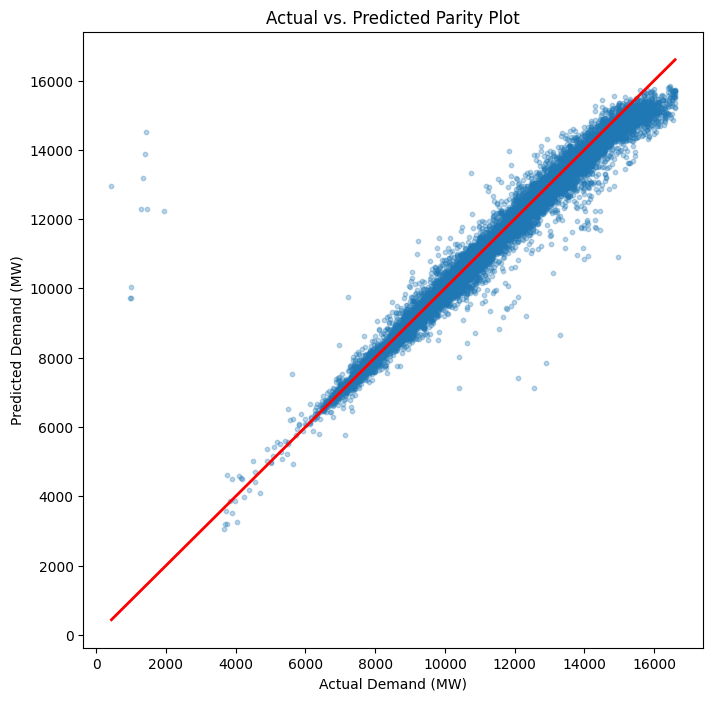

In [ ]:
plt.figure(figsize=(8, 8))
y_test = y_val
y_pred = best_model.predict(X_val)
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Demand (MW)')
plt.ylabel('Predicted Demand (MW)')
plt.title('Actual vs. Predicted Parity Plot')
plt.savefig('parity_plot.png')

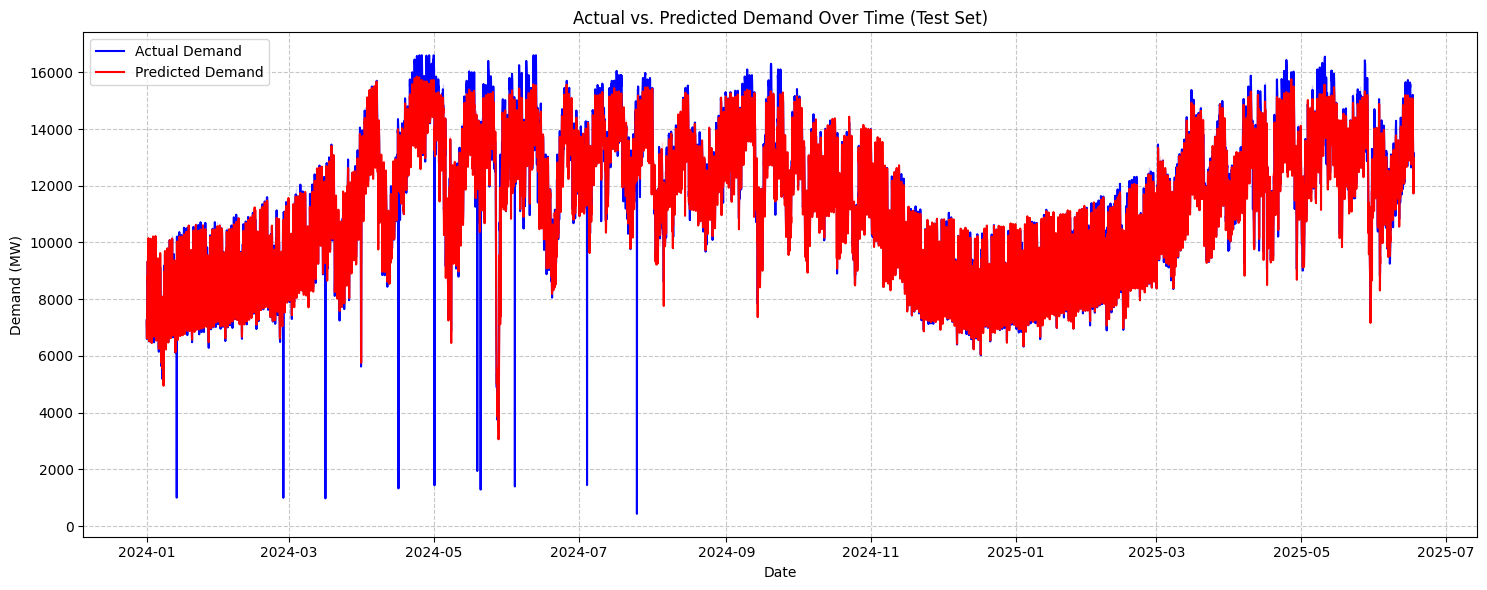

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=y_test.index, y=y_test, label='Actual Demand', color='blue')
sns.lineplot(x=y_test.index, y=y_pred, label='Predicted Demand', color='red')
plt.title('Actual vs. Predicted Demand Over Time (Test Set)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
mape_best_model = mean_absolute_percentage_error(y_val, y_pred)
print(f'MAPE for the best model: {mape_best_model:.2%}')

MAPE for the best model: 2.89%


In [ ]:
from sklearn.metrics import mean_absolute_error
mae_best_model = mean_absolute_error(y_val,y_pred)
print(f'MAE for the best model: {mae_best_model}:.2%')